<a href="https://colab.research.google.com/github/lkostenko/skelar/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.express as px

In [4]:
path = '/content/drive/MyDrive/курс Аналітик/Test Tasks/Skelar/Файл 1.csv'

In [5]:
df = pd.read_csv(path)

In [6]:
df.head()

,moderator,id_request,request_time,start_time,finish_time,team
0,165,159660,2020-09-24 7:01:16,2020-10-01 16:00:31,2020-10-01 16:02:02,retail
1,178,160116,2020-09-24 22:32:15,2020-10-01 13:21:42,2020-10-01 13:21:43,retail
2,187,160178,2020-09-25 2:58:13,2020-10-02 11:37:16,2020-10-02 11:41:56,wholesale
3,178,160306,2020-09-25 9:44:12,2020-10-02 7:23:09,2020-10-02 7:25:33,retail
4,178,163042,2020-09-30 15:56:08,2020-10-02 7:37:33,2020-10-02 7:47:57,retail


Перевірю інформацію по даних

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35617 entries, 0 to 35616
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   moderator     35617 non-null  int64 
 1   id_request    35617 non-null  int64 
 2   request_time  35617 non-null  object
 3   start_time    35617 non-null  object
 4   finish_time   35617 non-null  object
 5   team          35617 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.6+ MB


Бачу, що пропущених значень немає.

request_time, start_time, finish_time мають тип object, хоча це дати. Тому переведу їх в datetime, щоб можна було аналізувати час

In [8]:
df['request_time'] = pd.to_datetime(df['request_time'])
df['start_time'] = pd.to_datetime(df['start_time'])
df['finish_time'] = pd.to_datetime(df['finish_time'])

Далі я б хотіла створити нові колонки, де буде відображено час відповіді та час обробки запиту:

In [37]:
df['response_time_min'] = (df['start_time'] - df['request_time']).dt.total_seconds() / 60
df['handling_time_min'] = (df['finish_time'] - df['start_time']).dt.total_seconds() / 60

Подивлюсь середній час відповіді по командах:

In [10]:
df.groupby('team')['response_time_min'].mean().round(2)

,response_time_min
team,
retail,607.79
wholesale,3677.49


Бачу, що в обох командах середній час відповіді значно перевищую 15хвилин

Retail: 607.79 хв  ~10 годин

Wholesale: 3677.49 хв  ~61 година


Подивлюсь на медіану

In [11]:
df.groupby('team')['response_time_min'].median()

,response_time_min
team,
retail,48.383333
wholesale,3749.766667


так, як mean and median відрізняються , я б хотіла подивитись на розподіл даних

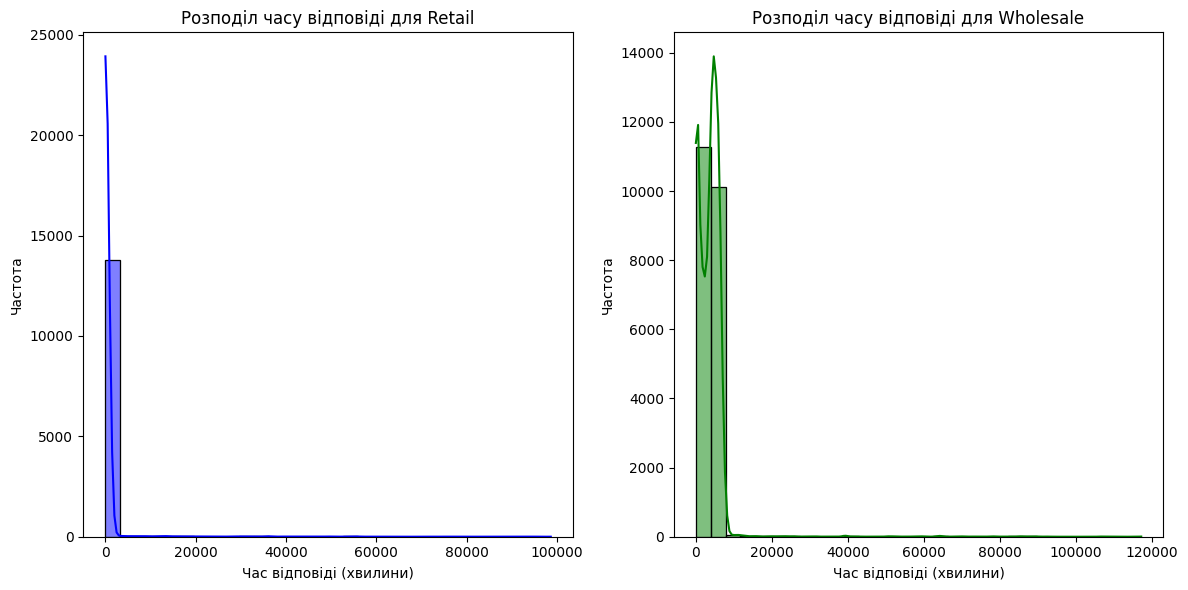

In [12]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
sns.histplot(df[df['team'] == 'retail']['response_time_min'], kde=True, color='blue', bins=30)
plt.title('Розподіл часу відповіді для Retail')
plt.xlabel('Час відповіді (хвилини)')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.histplot(df[df['team'] == 'wholesale']['response_time_min'], kde=True, color='green', bins=30)
plt.title('Розподіл часу відповіді для Wholesale')
plt.xlabel('Час відповіді (хвилини)')
plt.ylabel('Частота')

plt.tight_layout();

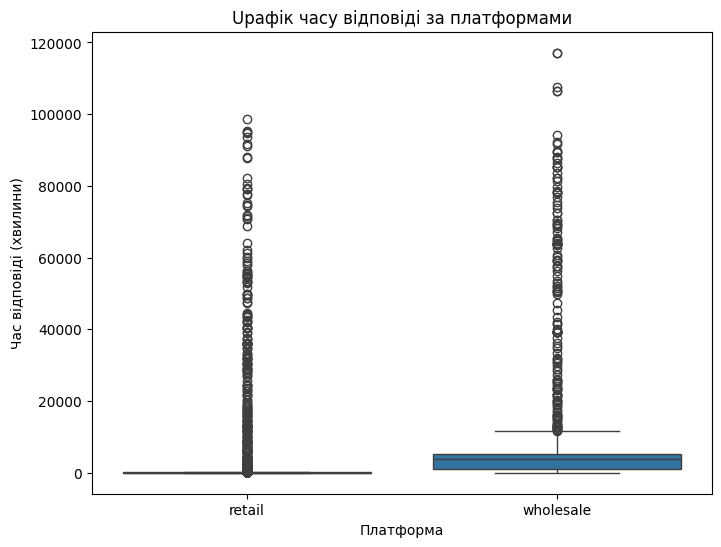

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='team', y='response_time_min', data=df)
plt.title('Графік часу відповіді за платформами')
plt.xlabel('Платформа')
plt.ylabel('Час відповіді (хвилини)');

З графіку видно, що є аутлаєри - медіана буде кращим показником центральної тенденції, бо вона менш чутлива до викидів.

Згідно з даними, середній час відповіді (за медіаною):

Retail: 48.38 хв

Wholesale: 3749.77 хв (~62 години)


Retail: середній час відповіді в межах 48 хвилин вказує на те, що для більшості запитів час відповіді є досить прийнятним.

Wholesale: середній час відповіді для цієї категорії виглядає дуже високим, що вказує на те, що більшість запитів займають понад 62 години. Це може свідчити про серйозні проблеми в обробці запитів на платформі гуртових продажів.

Перевірю частку запитів із часом відповіді понад 45 хв

In [14]:
(df[df['response_time_min'] > 45].groupby('team').size() / df.groupby('team').size()).round(2)

,0
team,
retail,0.53
wholesale,0.95


Retail: 53% — більше половини запитів обробляються із значним запізненням.

Wholesale: 95% — майже всі відповіді надходять із затримкою

Хочу подивитись динаміку в часі

In [15]:
df['request_date'] = pd.to_datetime(df['request_time']).dt.date

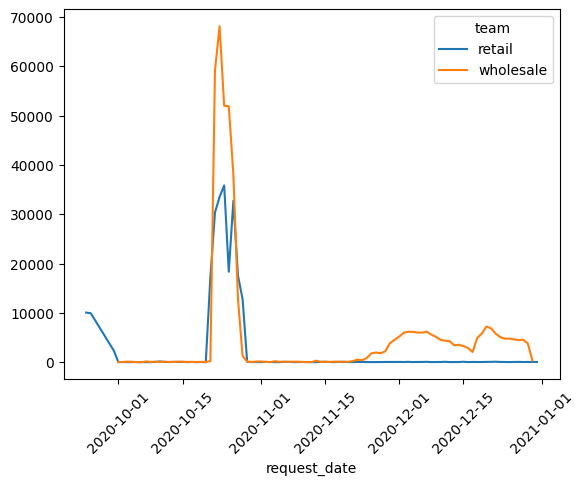

In [16]:
df.groupby(['request_date', 'team'])['response_time_min'].median().unstack().plot(rot=45);

Бачу певні піки на графіку, тому хочу подивитись детальніше на них:

In [17]:
df['request_date'] = pd.to_datetime(df['request_date'])
mask = (df['request_date'] >= '2020-10-19') & (df['request_date'] <= '2020-10-31')
df_peak = df[mask]

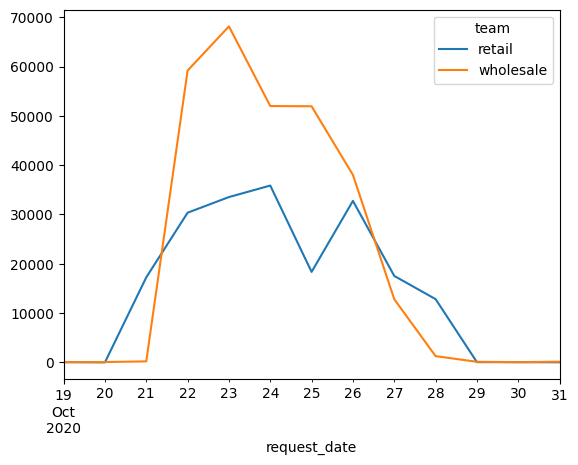

In [18]:
df_peak.groupby(['request_date', 'team'])['response_time_min'].median().unstack().plot();

Перевірю чому з 2020-10-20 по 2020-10-27 час відповіді був аномально високим

Кількість запитів до служби підтримки з 20 по 27 жовтня 2020

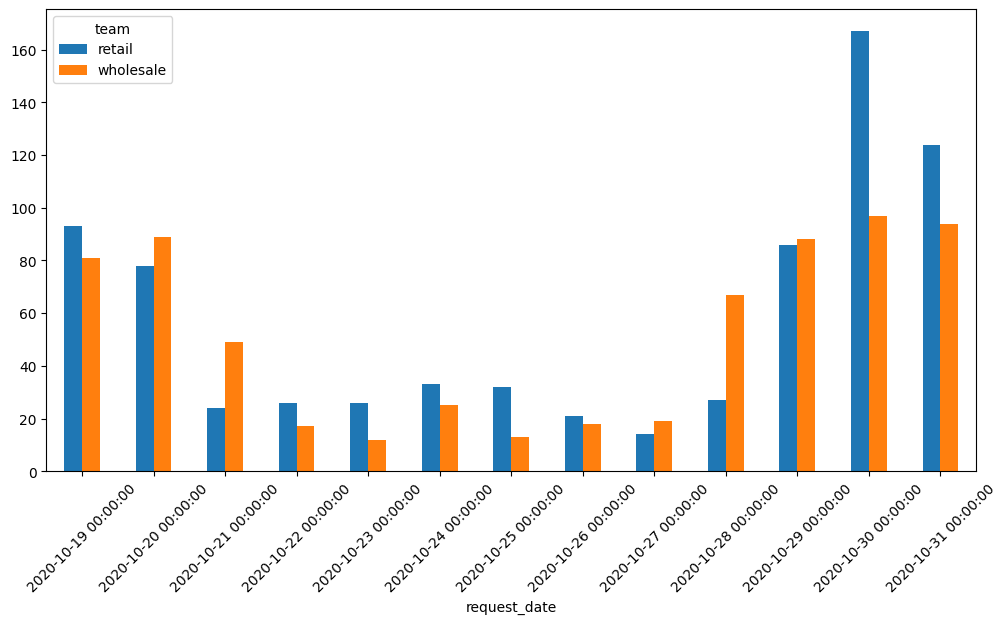

In [19]:
df_peak.groupby(['request_date', 'team']).size().unstack().plot(kind='bar', figsize=(12, 6), rot=45);

Кількість запитів до служби підтримки за весь період

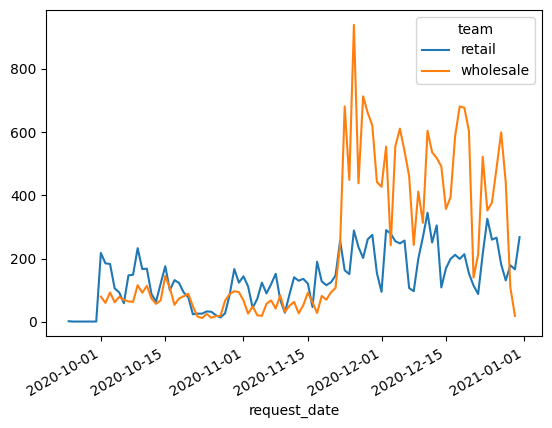

In [20]:
df.groupby(['request_date', 'team']).size().unstack().plot(kind='line');

На графіку видно, що між 2020-10-20 і 2020-10-27 було найменше запитів

В період з 2020-10-20 по 2020-10-27 було найменше запитів, але час відповіді був аномально високим

Порівняння команд за часом обробки

In [58]:
df.groupby('team')['handling_time_min'].median().round(2)

,handling_time_min
team,
retail,1.32
wholesale,1.45


**Аналіз роботи агентів:**

Середній час відповіді по кожному агенту

In [21]:
df.groupby('moderator')['response_time_min'].median().round(2).sort_values(ascending=False)

,response_time_min
moderator,
126,5996.45
180,4907.93
181,4576.58
187,4518.68
102,4489.03
112,4484.40
170,4378.81
149,3891.68
123,3882.53


З результатів видно:



*   moderator 126: середній час відповіді 5996 хв ~4 дні
*   moderator 180, 181, 187 і ще кілька — мають медіани понад 3000-4000 хв
*   moderator 129, 138, 134 — середній час відповіді менше ніж 1 хвилина




Скільки часу в середньому модератори витрачають на одне звернення

In [44]:
df.groupby('moderator')['handling_time_min'].median().sort_values(ascending=False).round(2)

,handling_time_min
moderator,
133,10.72
150,5.28
149,3.35
167,3.19
129,2.88
175,2.42
185,2.20
123,2.16
161,2.10


Розподіл часу обробки

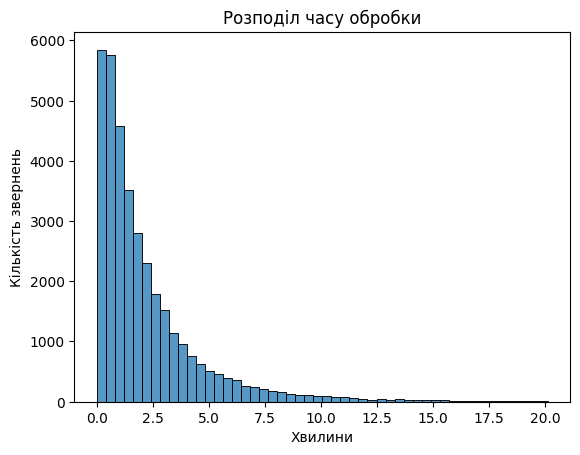

In [48]:
sns.histplot(df['handling_time_min'], bins=50)
plt.title('Розподіл часу обробки')
plt.xlabel('Хвилини')
plt.ylabel('Кількість звернень');

Більшість замовлень обробляється досить швидко

In [50]:
handling_stats = df.groupby('moderator').agg(
    median_handling_time_min=('handling_time_min', 'median'),
    request_count=('handling_time_min', 'count')
).round(2).sort_values(by='median_handling_time_min', ascending=False)

handling_stats

,median_handling_time_min,request_count
moderator,,
133,10.72,2
150,5.28,16
149,3.35,751
167,3.19,536
129,2.88,1
175,2.42,420
185,2.20,25
123,2.16,1452
161,2.10,181


In [54]:
fig = px.scatter(
    handling_stats.reset_index(),
    x='median_handling_time_min',
    y='request_count',
    size='request_count',
    color='median_handling_time_min',
    color_continuous_scale='Viridis',
    hover_name='moderator',
    title='Медіанний час обробки vs кількість запитів'
)
fig.show()

Дуже висока медіана у модераторів 133 (10.72 хв), 150 (5.28 хв), 149 (3.35 хв), що може свідчити про складні кейси, низьку ефективність або потребу в додатковому навчанні.

Найбільше запитів у модератора 188 (3746 запитів), при цьому його медіана — дуже низька (0.72 хв) → приклад високої ефективності

Ідентифікую проблемних модераторів

In [22]:
slow_agents = df.groupby('moderator')['response_time_min'].median()
slow_agents = slow_agents[slow_agents > 1000].sort_values(ascending=False)

Скільки запитів вони обробляють

In [23]:
count_requests = df['moderator'].value_counts()

In [24]:
slow_agents_df = pd.DataFrame({
    'median_response_time_min': slow_agents,
    'request_count': count_requests[slow_agents.index]
})
slow_agents_df

,median_response_time_min,request_count
moderator,,
126,5996.450000,2
180,4907.933333,1349
181,4576.583333,1625
187,4518.683333,1193
102,4489.033333,1321
112,4484.400000,1717
170,4378.808333,1686
149,3891.683333,751
123,3882.533333,1452


Найгірша ситуація — у модератора 126: понад 5996 хв при всього 2 запитах — може свідчити про технічну помилку або пропущені запити

Модератори 180, 181, 112, 170, 123, 188 — обробили тисячі запитів, при цьому маючи вкрай поганий медіанний час відповіді. Це означає, що якість обслуговування великої кількості клієнтів постраждала.

Групую статистику по всіх модераторах

In [25]:
moderator_stats = df.groupby('moderator').agg(
    median_response_time=('response_time_min', 'median'),
    request_count=('id_request', 'count')
).reset_index()

In [26]:
moderator_stats

,moderator,median_response_time,request_count
0,102,4489.033333,1321
1,103,3251.483333,1313
2,109,42.400000,827
3,110,7.133333,1
4,111,44.750000,569
5,112,4484.400000,1717
6,114,44.950000,60
7,116,234.566667,580
8,117,26.216667,1251
9,121,55.266667,799


In [27]:
fig = px.scatter(
    moderator_stats,
    x='request_count',
    y='median_response_time',
    size='request_count',
    color='median_response_time',
    hover_name='moderator',
    title='Медіанний час відповіді vs Кількість запитів по модераторах',
    labels={
        'request_count': 'Кількість запитів',
        'median_response_time': 'Медіанний час відповіді (хв)'
    },
    color_continuous_scale='RdBu',
    size_max=60
)

fig.update_layout(template='plotly_white')
fig.show()


Деякі з модераторів обробляють велику кількість запитів — тобто або перевантажені, або потребують оптимізації процесів.

Модератори з найбільшими бульбашками та високим часом відповіді (правий верхній кут) — потребують негайної уваги.
Вони обробляють багато запитів, але дуже повільно, що сильно впливає на якість обслуговування.

Я вважаю, що команда підтримки не справляється з поточним обсягом запитів.
Це не просто випадкові затримки, це системна перевантаженість — особливо в wholesale

Скільки людей ще потрібно:
*  1 агент здатен виконати 1 запит ≤ 5 хв
*  Тобто за 1 годину: 12 запитів
*  За 8 годин роботи: ~96 запитів/день

In [28]:
team_counts = df.groupby('team')['id_request'].count()
team_counts

,id_request
team,
retail,14025
wholesale,21592


In [29]:
team_days = df.groupby('team')['request_time'].apply(lambda x: x.dt.date.nunique())
team_days

,request_time
team,
retail,95
wholesale,92


In [30]:
avg_requests_per_day = team_counts / team_days
avg_requests_per_day

,0
team,
retail,147.631579
wholesale,234.695652


In [31]:
agents_needed = (avg_requests_per_day / 96).round()
agents_needed

,0
team,
retail,2.0
wholesale,2.0


wholesale:

Має дуже високі часи відповіді (медіани > 3000–4000 хв)

І хоча агентів формально потрібно 2–3, здається, що працюючих агентів недостатньо або вони перевантажені

Можливі причини:

Не всі агенти працюють повний день. Можливо, дехто обробляє лише 10–20 запитів на день.

Поганий розподіл навантаження. Є модератори із >3000 запитів і дуже високим часом відповіді → хтось перевантажений, хтось майже не працює.

Деякі агенти не відповідають дні/тижні. Це тягне медіану догори.

Рекомендації:

*  Не лише додати агентів, але й розподіляти навантаження рівномірніше

*  Ввести KPI по median response time, а не лише к-сті запитів

*  Зробити аудит модераторів із >1000 хв медіани — чому такі затримки?

РОзрахую KPI для кожного модератора

In [32]:
moderator_kpi = df.groupby('moderator')['response_time_min'].median().reset_index()
moderator_kpi.columns = ['moderator', 'median_response_time_min']

def classify_kpi(median):
    if median <= 15:
        return 'Good'
    elif median <= 45:
        return 'Acceptable'
    else:
        return 'Needs improvement'

moderator_kpi['KPI_status'] = moderator_kpi['median_response_time_min'].apply(classify_kpi)


In [33]:
moderator_kpi

,moderator,median_response_time_min,KPI_status
0,102,4489.033333,Needs improvement
1,103,3251.483333,Needs improvement
2,109,42.400000,Acceptable
3,110,7.133333,Good
4,111,44.750000,Acceptable
5,112,4484.400000,Needs improvement
6,114,44.950000,Acceptable
7,116,234.566667,Needs improvement
8,117,26.216667,Acceptable
9,121,55.266667,Needs improvement


KPI менеджменту не досягається:

Очікування менеджменту — відповідь протягом 15 хв, і не більше 45 хв у гірших випадках.

Лише ~20% модераторів реально тримаються в цих рамках.

Це означає, що відділ підтримки системно не відповідає очікуванням.

Аналіз пікових навантажень по годинах

In [34]:
df['hour'] = df['request_time'].dt.hour

In [64]:
hourly_stats = df.groupby('hour').agg(
    request_count=('request_time', 'count'),
    median_response_time_min=('response_time_min', 'median'),
    median_handling_time_min=('handling_time_min', 'median')
).reset_index()
hourly_stats

,hour,request_count,median_response_time_min,median_handling_time_min
0,0,7,5306.633333,0.700000
1,6,3,481.666667,2.300000
2,7,3489,437.166667,1.650000
3,8,2967,2283.550000,1.683333
4,9,3443,452.066667,1.483333
5,10,2938,1972.200000,1.516667
6,11,3403,123.250000,1.450000
7,12,2639,1757.833333,1.300000
8,13,2929,80.416667,1.450000
9,14,2145,670.083333,1.583333


9:00–13:00 — це пікові години за кількістю запитів:

9:00 → 3443 запити

11:00 → 3403 запити

10:00 → 2938 запити

8:00 → 2967 запити

13:00 → 2929 запити

Потрібно забезпечити максимальну кількість операторів у цей час. Саме в ці години потрібне підсилення команди.

Найгірші показники response_time_min:

0:00 — 5306 хв ( всього 7 запитів — можливо, залишені на потім)

8:00 — 2283 хв

10:00 — 1972 хв

22:00 — 2475 хв

23:00 — 2303 хв

навіть у години з високим трафіком оператори не встигають швидко реагувати. Це ознака недостатньої кількості активних агентів або поганої організації чергування.

 Handling time стабільне (і коротке):
~1.2–1.6 хвилин у більшості годин, ще означає, що коли оператор бере в роботу запит, він справляється швидко


Після 17:00 кількість запитів зменшується, але response time часто залишається високим (наприклад, 18:00 — 2035 хв)

можливо, в цей час мало або взагалі немає агентів онлайн, тому нові запити висять до ранку.

**Рекомендації:**

Переглянути графік чергування.
У пікові години (8:00–13:00) потрібно більше агентів.

Вечірні зміни — підсилити
З 18:00 до 23:00 response time часто дуже високий, навіть при невеликій кількості запитів.

Оцінити нічні кейси (0:00–6:00):
Чи справді потрібна підтримка в ці години, чи краще офіційно ввести нічну паузу

Порівняю пікові години запитів по кожній команді

In [68]:
hourly_team_requests= df.groupby(['team', 'hour'])['request_time'].count().unstack('team').fillna(0)
hourly_team_requests

team,retail,wholesale
hour,,
0,0.0,7.0
6,2.0,1.0
7,1474.0,2015.0
8,617.0,2350.0
9,1379.0,2064.0
10,713.0,2225.0
11,1590.0,1813.0
12,869.0,1770.0
13,1814.0,1115.0


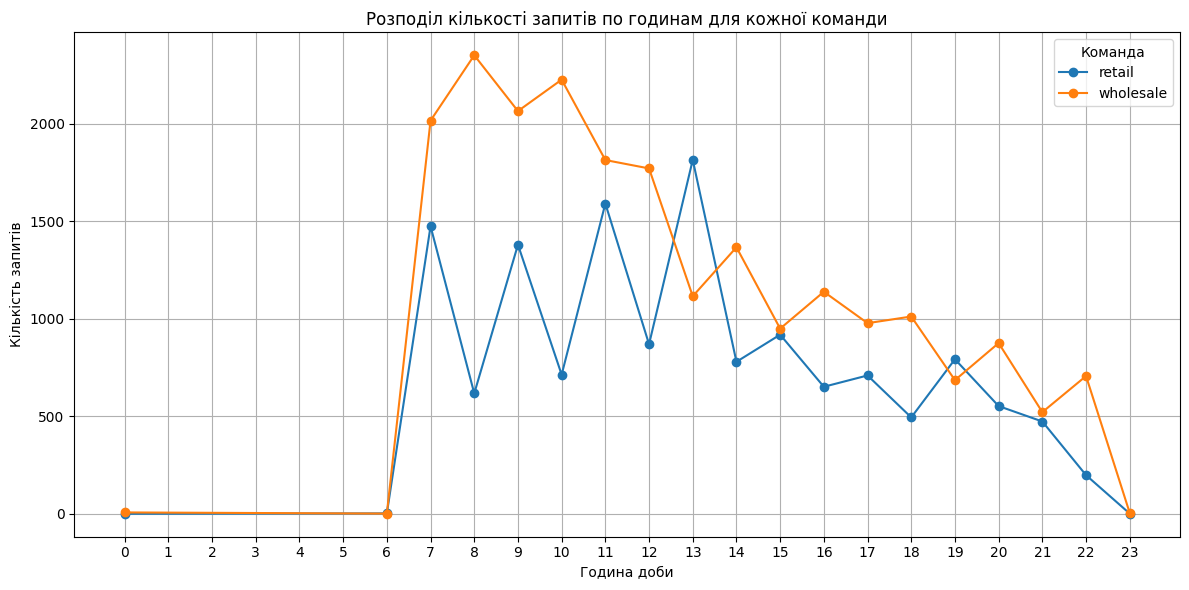

In [71]:
plt.figure(figsize=(12, 6))
for team in hourly_team_requests.columns:
    plt.plot(hourly_team_requests.index, hourly_team_requests[team], label=team, marker='o')

plt.title('Розподіл кількості запитів по годинам для кожної команди')
plt.xlabel('Година доби')
plt.ylabel('Кількість запитів')
plt.legend(title='Команда')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout();

Ранок (з 7:00 до 9:00) є основним періодом високої активності для обох команд, при цьому обсяг запитів на оптовому ринку є вищим порівняно з роздрібним.

У Команді Retail у 13:00 ще одна пікова година, коли кількість запитів значно зростає.

### Основні проблеми:
1. **Низька ефективність в обробці запитів:**
   - В **wholesale** медіанний час відповіді вражаюче високий, з багатьма модераторами, які мають час відповіді понад 3000–4000 хвилин (~50–60 годин). Це свідчить про системні затримки в обробці запитів.
   - Навіть в пікові години, коли запитів багато, response time залишається високим. Це може бути через **недостатню кількість агентів**, погану організацію чергувань, або обмежену кількість модераторів, які працюють у ключові години.
  
2. **Проблеми з розподілом навантаження:**
   - Здається, що робота між модераторами розподілена нерівномірно: деякі обробляють тисячі запитів за короткий час, в той час як інші — дуже мало або взагалі нічого.
   - Модератори з **високими медіанними показниками** (більше 1000 хвилин) потребують уваги: можливо, вони працюють з більш складними запитами, перевантажені або мають потребу в додатковому навчанні.

3. **Невідповідність стандартам KPI:**
   - Менеджмент має високі вимоги до часу відповіді (15 хвилин в ідеалі, до 45 хвилин в критичних випадках), але тільки **20% модераторів** дотримуються цих вимог.
   - **KPI для часів відповіді** не досягаються, і це потребує уваги для поліпшення ефективності роботи відділу.

### Рекомендації:
1. **Розподіл навантаження:**
   - Потрібно **оптимізувати процеси** і рівномірно розподіляти навантаження між модераторами, щоб уникнути перевантаження.
   - Звернути увагу на модераторів з високим часом відповіді (особливо в wholesale), щоб зрозуміти причини затримок та вирішити проблеми.

2. **Перегляд чергування та графіків:**
   - В пікові години (9:00–13:00) потрібно забезпечити **максимальну кількість операторів** для обробки запитів.
   - Вечірні зміни (18:00–23:00) потребують підсилення, оскільки **response time залишається високим** навіть при зниженому обсязі запитів.

3. **Оцінка необхідності нічної підтримки:**
   - Переглянути, чи справді потрібна підтримка в нічні години (0:00–6:00), чи краще зробити паузу в ці години.

4. **Додати більше агентів:**
   - **Кількість агентів недостатня** для обробки поточного обсягу запитів. Потрібно додати більше людей в команду, особливо в періоди високого навантаження.
  
5. **Навчання та підтримка модераторів:**
   - Модераторам з **поганими показниками** потрібно провести додаткове навчання або оптимізувати їх роботи для підвищення ефективності.

### Висновок:
Наразі, команда підтримки не справляється з поточним обсягом запитів, і це призводить до значних затримок, особливо в категорії wholesale. Потрібно вжити заходів для покращення організації роботи, розподілу навантаження та забезпечення достатньої кількості агентів в пікові години, а також оптимізувати роботу модераторів для досягнення встановлених стандартів відповіді.